In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
df = fetch_openml("mtp", version=1)

df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


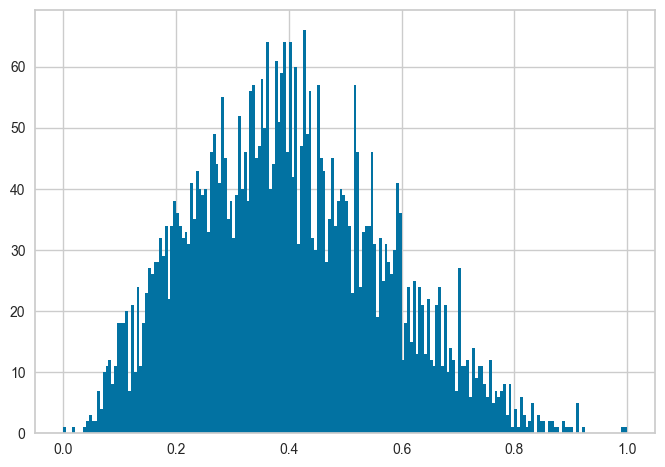

In [10]:
plt.hist(df.target, 200)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [14]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340779227983

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

Text(0.5, 0, 'Feature Importance')

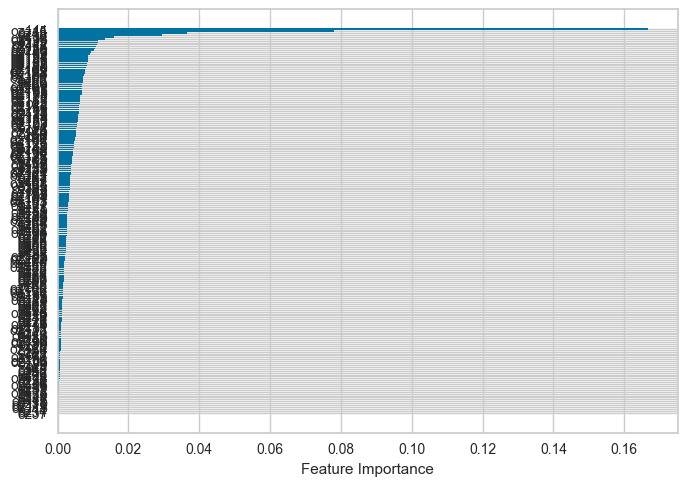

In [24]:
sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

In [25]:
rf.feature_importances_[sort][-10:]

array([0.01093886, 0.01125355, 0.01128566, 0.01129342, 0.01345764,
       0.01605691, 0.02936816, 0.03651167, 0.07806206, 0.16670859])

In [26]:
df.data.columns[sort][-10:]

Index(['oz155', 'oz117', 'oz112', 'oz35', 'oz198', 'oz137', 'oz18', 'oz48',
       'oz15', 'oz141'],
      dtype='object')

In [27]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz170,oz161,oz162,oz146,oz187,oz154,oz157,oz163,oz158,oz20,oz155,oz117,oz112,oz35,oz198,oz137,oz18,oz48,oz15,oz141
0,0.866163,0.382067,0.319206,0.011997,0.017299,0.030205,0.000000,0.059438,0.800120,0.000000,0.752291,0.000000,0.000000,0.0,0.039213,0.000000,0.0625,0.312855,0.000000,0.041308
1,0.866069,0.383458,0.306084,0.025932,0.146552,0.016908,0.000281,0.122765,0.791224,0.242424,0.745984,0.311793,0.222222,0.4,0.326584,0.278945,0.0625,0.297041,0.282828,0.212274
2,0.866224,0.382596,0.406309,0.007666,0.061102,0.006922,0.001852,0.153984,0.798276,0.388889,0.753298,0.000000,0.000000,0.0,0.204885,0.000000,0.1250,0.288557,0.388889,0.063643
3,0.865988,0.382776,0.327848,0.021463,0.053542,0.001240,0.000158,0.110089,0.800965,0.095238,0.767469,0.000000,0.000000,0.1,0.023469,0.039437,0.0000,0.310692,0.111111,0.031193
4,0.866283,0.383539,0.329857,0.006780,0.026084,0.011829,0.000037,0.075031,0.802893,0.260870,0.741548,0.000000,0.000000,0.0,0.111398,0.000000,0.0625,0.286581,0.304348,0.063643


In [28]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340779227983


0.3513560906073073

In [30]:
df.data.shape

(4450, 202)

In [31]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 49)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340779227983


0.4304475568027031

In [33]:
df = fetch_openml("balance-scale", version=1)

df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


In [34]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

In [35]:
baseline = LogisticRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

0.8598726114649682

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



In [37]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [38]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

In [39]:
weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train, y_train)
print(bl_score)
weighted.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [40]:
print(classification_report(y_test, weighted.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



In [41]:
y_train.value_counts()

class
R    216
L    215
B     37
Name: count, dtype: int64

In [42]:
X_train["target"] = y_train

In [43]:
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)

In [44]:
oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


In [46]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(["target"], axis=1)

In [47]:
OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(bl_score)
OSmodel.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [48]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(["instance_id"], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_61083/1011001378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.data.drop(["instance_id"], inplace=True, axis=1)


,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


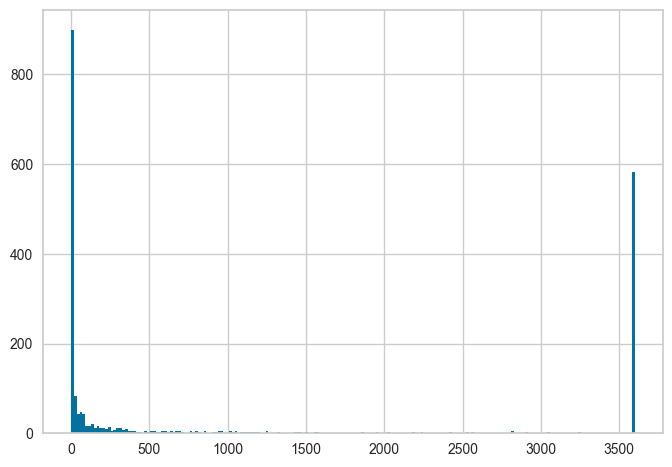

In [50]:
plt.hist(df.target, 200)
_ = plt.plot()

In [51]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

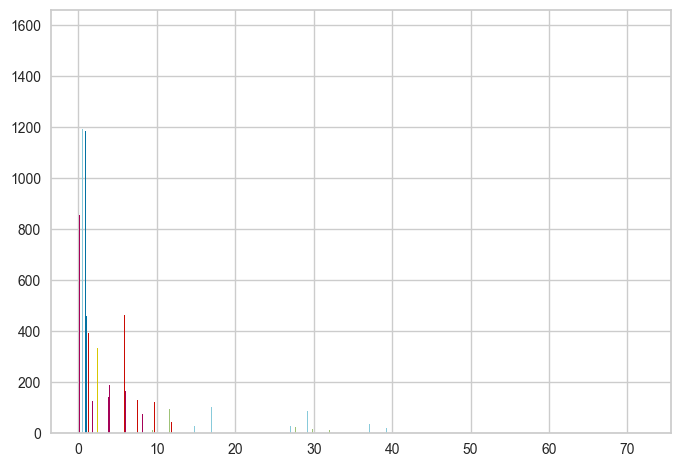

In [63]:
plt.hist(X_train, 100)
plt.show()

In [64]:
from sklearn.preprocessing import KBinsDiscretizer

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))

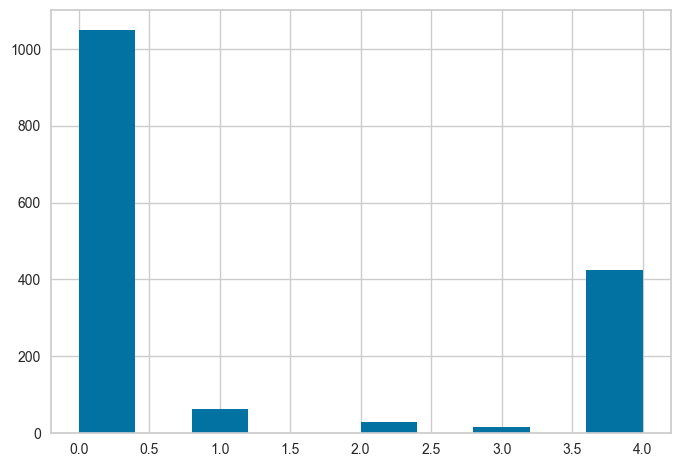

In [67]:
plt.hist(y_binned)
_ = plt.plot()

In [68]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


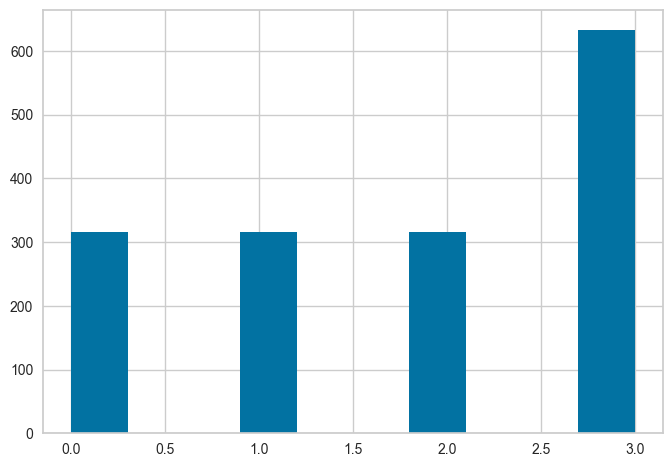

In [69]:
plt.hist(y_binned)
_ = plt.plot()

## Практическая работа

### 1. Связь между количеством важных признаков и точностью модели

In [76]:
df = fetch_openml("mtp", version=1)
X = df.data
y = df.target

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [78]:
rf = RandomForestRegressor(n_estimators=15, random_state=42)
rf.fit(X_train, y_train)
importance = rf.feature_importances_
sorted_idx = np.argsort(importance)

In [79]:
n_features = [5, 10, 20, 30, 50, 70, 100, 150, 202]
scores = []

In [83]:
for n in n_features:
    top_features = X.columns[sorted_idx[-n:]]
    X_train_trim = X_train[top_features]
    X_test_trim = X_test[top_features]
    
    model = LinearRegression()
    model.fit(X_train_trim, y_train)
    score = model.score(X_test_trim, y_test)
    scores.append(score)
    print(f"Признаков: {n}, R2 = {score:.4f}")

Признаков: 5, R2 = 0.2861
Признаков: 10, R2 = 0.3107
Признаков: 20, R2 = 0.3538
Признаков: 30, R2 = 0.3763
Признаков: 50, R2 = 0.4158
Признаков: 70, R2 = 0.4447
Признаков: 100, R2 = 0.4599
Признаков: 150, R2 = 0.4863
Признаков: 202, R2 = -1.6511


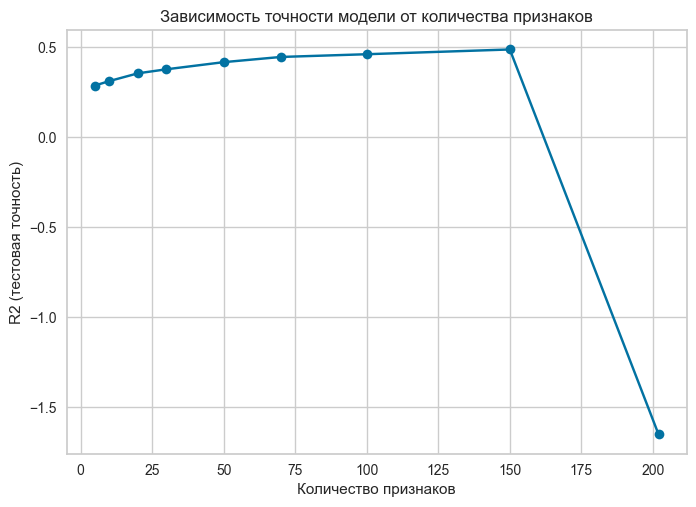

In [82]:
plt.plot(n_features, scores, marker='o')
plt.xlabel('Количество признаков')
plt.ylabel('R2 (тестовая точность)')
plt.title('Зависимость точности модели от количества признаков')
plt.grid(True)
plt.show()

### 2. Другие методы отбора признаков

In [84]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, RFE, SequentialFeatureSelector
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

In [85]:
df = fetch_openml("mtp", version=1)
X, y = df.data, df.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [86]:
def evaluate(X_tr, X_te):
    model = LinearRegression()
    model.fit(X_tr, y_train)
    return model.score(X_te, y_test)

results = {}

In [87]:
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)
results['VarianceThreshold'] = evaluate(X_var, X_test_var)
print(f"VarianceThreshold: {results['VarianceThreshold']:.4f}, признаков: {X_var.shape[1]}")

VarianceThreshold: -1.4759, признаков: 134


In [88]:
selector = SelectKBest(f_regression, k=30)
X_freg = selector.fit_transform(X_train, y_train)
X_test_freg = selector.transform(X_test)
results['SelectKBest'] = evaluate(X_freg, X_test_freg)
print(f"SelectKBest: {results['SelectKBest']:.4f}")

SelectKBest: 0.4204


In [90]:
selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=30, direction='forward', cv=3)
X_sfs = selector.fit_transform(X_train, y_train)
X_test_sfs = selector.transform(X_test)
results['SFS'] = evaluate(X_sfs, X_test_sfs)
print(f"SFS: {results['SFS']:.4f}")

SFS: 0.4555


In [91]:
selector = Lasso(alpha=0.01, random_state=42)
selector.fit(X_train, y_train)
selected = np.abs(selector.coef_) > 0
X_lasso = X_train.loc[:, selected]
X_test_lasso = X_test.loc[:, selected]
results['Lasso'] = evaluate(X_lasso, X_test_lasso)
print(f"Lasso: {results['Lasso']:.4f}, признаков: {X_lasso.shape[1]}")

Lasso: 0.1740, признаков: 1


In [93]:
for method, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{method}: {score:.4f}")

SFS: 0.4555
SelectKBest: 0.4204
Lasso: 0.1740
VarianceThreshold: -1.4759


VarianceThreshold убирает почти константные признаки;  
SelectKBest выбирает признаки по статистической связи с целью;  
SequentialFeatureSelector добавляет признаки пошагово;  
Lasso зануляет лишние коэффициенты.

### 3. imbalanced-learn

In [100]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

In [97]:
df = fetch_openml("balance-scale", version=1)
X, y = df.data, df.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [98]:
def test_sampler(sampler, name):
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    score = LogisticRegression(max_iter=1000).fit(X_res, y_res).score(X_test, y_test)
    print(f"{name}: {score:.4f}")

In [101]:
test_sampler(RandomOverSampler(random_state=42), "RandomOverSampler")
test_sampler(SMOTE(random_state=42), "SMOTE")
test_sampler(RandomUnderSampler(random_state=42), "RandomUnderSampler")

RandomOverSampler: 0.9236
SMOTE: 0.8854
RandomUnderSampler: 0.8726


Добавление копии объектов миноритарного класса (RandomOverSampler) лидирует в результате

RandomOverSampler — случайно дублирует объекты миноритарного класса, быстро балансирует данные, но может приводить к переобучению.  
SMOTE — генерирует синтетические объекты миноритарного класса на основе ближайших соседей, снижает переобучение по сравнению с простым дублированием, но может создавать не совсем реалистичные точки.  
RandomUnderSampler — случайно удаляет объекты мажоритарного класса, упрощает модель и ускоряет обучение, но может приводить к потере важной информации.

### 4. Исследуйте влияние дискретизации целевой переменной на качество модели

In [108]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [103]:
df = fetch_openml("CPMP-2015-regression", version=1)
X = df.data.drop(['instance_id'], axis=1)
X = pd.get_dummies(X)
y = df.target

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [109]:
for strategy in ['uniform', 'quantile', 'kmeans']:
    for n_bins in [3, 5, 7, 10]:
        disc = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
        y_train_bin = disc.fit_transform(y_train.values.reshape(-1, 1)).ravel()
        y_test_bin = disc.transform(y_test.values.reshape(-1, 1)).ravel()
        
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train_bin)
        acc = accuracy_score(y_test_bin, clf.predict(X_test))
        print(f"{strategy}, bins={n_bins}: {acc:.4f}")

uniform, bins=3: 0.9412
uniform, bins=5: 0.9222
uniform, bins=7: 0.8937
uniform, bins=10: 0.8937
quantile, bins=3: 0.8387
quantile, bins=5: 0.7343
quantile, bins=7: 0.6641
quantile, bins=10: 0.5901
kmeans, bins=3: 0.9279
kmeans, bins=5: 0.9070
kmeans, bins=7: 0.8349
kmeans, bins=10: 0.8254


- **Uniform** показала лучшие результаты (до **94.1%** при 3 категориях)
- С увеличением числа категорий точность снижается
- **Quantile** работает хуже из-за неравномерного исходного распределения
- **Оптимально:** uniform с 3–5 категориями

- uniform — равномерные интервалы
Делит диапазон значений на n_bins равных по длине интервалов
- quantile — квантильные интервалы
Делит так, чтобы в каждом интервале было одинаковое количество объектов
- kmeans — кластеризация
Использует алгоритм k-means для группировки значений в кластеры